# **10 · P2 Data Understanding — 7개년(2019~2025) 데이터는 '이어붙여도 되는' 데이터인가**

### **"인코딩 3종·가중치명 4종·변수명 직결 불가·2022 대표본 — 네 개의 함정을 코드로 들춰내 통합의 전제를 점검한다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 분석 단위 = **연도(2019~2025) × 응답자** · 방법 = 7개년 메타 실측·crosswalk 가용성 검사

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **① 데이터 파악·문제정의** · CRISP-DM **P1·P2(Business·Data Understanding)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 7개년 `.sav`를 **변수명으로 그냥 이어붙일 수 있는가** — 인코딩·가중치명·문항번호 체계는 연도 간 일관되는가?
> **Q2.** 2022의 비정상적으로 큰 N은 **오류인가, 구조인가** — 통합 패널에서 어떻게 다뤄야 하는가?
> **Q3.** 다음 단계(전처리·MGCFA)의 **잠재요인 입력 지표**(신뢰성 배터리)는 7개년 비교 가능한 형태로 존재하는가?

→ 이 노트북은 *분석 결론을 내지 않는다*. 마스터플랜이 "발견"이라 적은 7개년 정합성 난제를 **코드로 직접 재현**해, 통합(P3)·모델링(P4)이 딛고 설 **데이터 이해**를 확정하는 P2 단계다.

## **목차**

| § | 내용 | 핵심 질문 |
|:--:|------|-----------|
| 1 | 7개년 메타 실측 | N·인코딩·가중치명 |
| 2 | 변수명 직결 불가 (+ DB①) | 통합 키 결정 |
| 3 | 2022 표본 이상 규명 | 오류 vs 구조 |
| 4 | 신뢰성 배터리 crosswalk | 잠재요인 입력 가용성 |
| 5 | 가용성 행렬 (+ DB②) | 결측 = 구조적 부재 |
| 6~7 | 검증·종합 | 입증·결론 |

> **thin 원칙**: 로직 정본은 `src/`다. 본 노트북은 `src/harmonize.py`·`src/extract_all_sav_meta.py`의 단계함수·상수를 import해 *과정과 중간 출력*을 보여줄 뿐, 로직을 재구현하지 않는다.
> ✅ **검증 게이트 해소**([data-spec.md](../docs/design/data-spec.md) §6 → [kpf-revalidation](../docs/design/kpf-revalidation.md), 2026-07-11): 아래 수치는 데이터 이해용 실측치이며, 원자료 재검증에서 공식 보고서와 **전 셀 일치**로 확정됐다(입증 노트북 `12` · 인용 자격등급 = p6-pdf-structure §3).
> **종합 문서**: [data-spec.md](../docs/design/data-spec.md) · [variable-crosswalk.md](../docs/design/variable-crosswalk.md) · [variable-crosswalk-trust-battery.md](../docs/design/variable-crosswalk-trust-battery.md) · [sav-meta-catalog.md](../docs/design/sav-meta-catalog.md)


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import pyreadstat

# 저장소 루트 탐색(노트북 cwd가 notebooks/든 루트든 견고)
ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz                 # P3 SSOT — 상수(SRC, CRED_BATTERY)·로더 재사용
print("ROOT =", ROOT)
print("대상 연도 =", hz.YEARS, "| T(균등화 분모) =", hz.T)

ROOT = C:\Users\kik32\workspace\Dacon\Media-Statistics-Analysis-and-Utilization-Competition\.claude\worktrees\media-stats-notebook-refactor-1a8b79
대상 연도 = [2019, 2020, 2021, 2022, 2023, 2024, 2025] | T(균등화 분모) = 7


## 1. 7개년 메타 실측 — N·변수수·인코딩·가중치

마스터플랜 §1 표를 *말이 아니라 코드로* 재현한다. 속도를 위해 `metadataonly=True`로
헤더만 읽되(전체 로드 불필요), `src`와 동일한 **인코딩 fallback(euc-kr→utf-8)** 정책을 그대로 적용한다.

In [2]:
def read_meta(path: Path):
    # 인코딩 순차 시도(euc-kr→utf-8)로 메타만 로드. src/harmonize.read_sav_any와 동일 정책.
    last = None
    for enc in hz.ENCODINGS:                 # ['euc-kr','utf-8'] — src 상수 재사용
        try:
            _, meta = pyreadstat.read_sav(str(path), metadataonly=True, encoding=enc)
            return meta, enc
        except Exception as e:
            last = e
    raise RuntimeError(f"{path.name}: 모든 인코딩 실패 → {last}")

WEIGHT_CANDS = {"wt1", "wt2", "WT", "HMWT", "wt", "hmwt"}
rows, META = [], {}
for y in hz.YEARS:
    meta, enc = read_meta(hz.SAV_BY_YEAR[y])
    META[y] = (meta, enc)
    names = list(meta.column_names)
    wts = [n for n in names if n in WEIGHT_CANDS]
    rows.append({"연도": y, "표본 N": meta.number_rows, "변수 수": meta.number_columns,
                 "인코딩": enc, "가중치 변수": ", ".join(wts)})
meta_tbl = pd.DataFrame(rows).set_index("연도")
meta_tbl

,표본 N,변수 수,인코딩,가중치 변수
연도,,,,
2019,5040,286,euc-kr,"wt1, wt2"
2020,5010,281,euc-kr,WT
2021,5010,307,utf-8,WT
2022,58936,244,utf-8,WT
2023,5000,245,euc-kr,HMWT
2024,6000,237,euc-kr,WT
2025,6000,223,euc-kr,WT


#### **[발견 ①] 7개년은 인코딩·가중치·표본이 3중으로 이질적이다**

- **인코딩 혼재** — euc-kr(2019·20·23·24·25) vs **utf-8(2021·2022)**. 단일 인코딩 로더가 2021에서 깨지므로 fallback이 필수다(아래 §1.1에서 fallback이 실제로 작동함을 입증).
- **가중치 변수명 4종** — `wt1/wt2`(2019)·`WT`(20·21·22·24·25)·`HMWT`(2023). → `src/harmonize.WEIGHT_BY_YEAR`로 표준 `WT` 통일.
- **2022 표본 이상** — N이 타 연도(5천~6천) 대비 압도적. 개인용 파일의 구조를 §3에서 규명.

→ **세 이질성 모두 '연도별로 다른 잣대'다. 변수명 직결로 합치면 깨진다 — §2에서 정량 확인. ① 메타 실측 — 완료.**

In [3]:
# §1.1 인코딩 fallback 입증: 2021(utf-8)을 euc-kr로 강제하면 실제로 예외가 나는가?
p2021 = hz.SAV_BY_YEAR[2021]
try:
    pyreadstat.read_sav(str(p2021), metadataonly=True, encoding="euc-kr")
    print("2021 euc-kr: 예외 없음(주의 — 무성 모자이크 가능성 점검 필요)")
except Exception as e:
    print("2021 euc-kr → 예외 발생 → fallback이 utf-8로 정상 전환:", type(e).__name__)
print("실측 인코딩(2021) =", META[2021][1])
# 라벨이 깨지지 않았는지(한글 정상) 확인 — 2025 인구통계 라벨 샘플
m25 = META[2025][0]
sample = {k: m25.column_names_to_labels.get(k) for k in list(m25.column_names)[:6]}
print("2025 라벨 샘플(한글 정상 디코드 확인):")
for k, v in sample.items():
    print(f"  {k}: {v}")

2021 euc-kr → 예외 발생 → fallback이 utf-8로 정상 전환: ReadstatError
실측 인코딩(2021) = utf-8
2025 라벨 샘플(한글 정상 디코드 확인):
  ID: 응답자 개별 ID
  SQ1: SQ1. 거주지역_시도
  DQ2: DQ2. 성별
  DQ3: DQ3. 연령
  Q1: 문1. 지난 일주일 간 종이신문 열독 여부
  Q2A_1: 문2A. 종이신문 열독 일수_평일


## 2. 변수명 직결 불가 — 문항번호 체계가 2~3년마다 리셋

7개년을 변수명으로 그냥 이어붙일 수 있는가? **인접연도 Jaccard 유사도**와 **7개년 공통 교집합 크기**로 확인한다.

In [4]:
namesets = {y: set(META[y][0].column_names) for y in hz.YEARS}
# 인접연도 Jaccard
jac = []
for a, b in zip(hz.YEARS[:-1], hz.YEARS[1:]):
    inter = len(namesets[a] & namesets[b]); uni = len(namesets[a] | namesets[b])
    jac.append({"구간": f"{a}-{b}", "공통 변수": inter, "Jaccard": round(inter/uni, 3)})
jac_tbl = pd.DataFrame(jac).set_index("구간")
common_all = set.intersection(*namesets.values())
print("7개년 공통 변수명 교집합:", len(common_all), "개 →", sorted(common_all))
jac_tbl

7개년 공통 변수명 교집합: 2 개 → ['Q1', 'SQ1']


,공통 변수,Jaccard
구간,,
2019-2020,44,0.084
2020-2021,248,0.729
2021-2022,52,0.104
2022-2023,53,0.122
2023-2024,200,0.709
2024-2025,142,0.447


**[시각화 ①] 변수명 직결 불가의 정량 증거** — (좌) 연도쌍 Jaccard 유사도 행렬: 문항번호 체계가 2~3년마다 리셋되어 인접연도조차 유사도가 낮고, 떨어진 연도쌍은 급락한다. (우) 연도별 변수 수와 7개년 공통 변수명(빨간 수평선 = 단 2개)의 대비 — '변수명 직결'이라는 선택지가 데이터에 존재하지 않음을 정량으로 보인다.

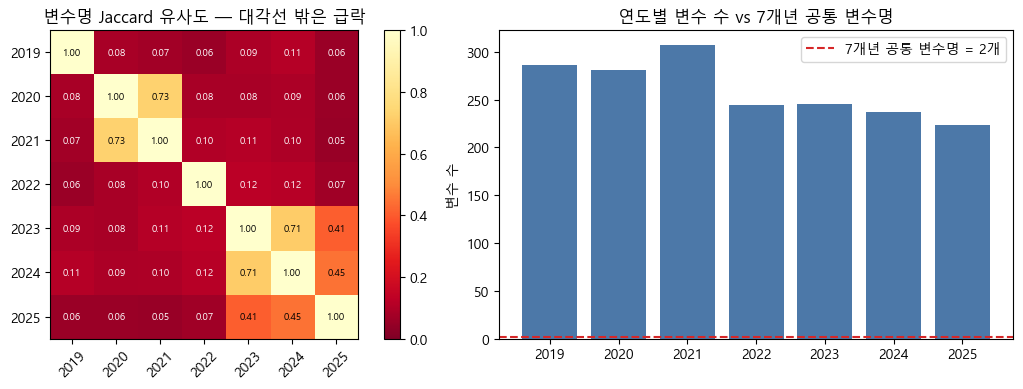

인접연도 Jaccard 범위 0.08~0.73 · 7개년 교집합 2개 → 직결 불가


In [5]:
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(nm, fallback_to_default=False)
        plt.rcParams["font.family"] = nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

Y = hz.YEARS
J = np.zeros((len(Y), len(Y)))
for i, a in enumerate(Y):
    for j, b in enumerate(Y):
        J[i, j] = len(namesets[a] & namesets[b]) / len(namesets[a] | namesets[b])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
im = axes[0].imshow(J, cmap="YlOrRd_r", vmin=0, vmax=1)
axes[0].set_xticks(range(len(Y))); axes[0].set_xticklabels(Y, rotation=45)
axes[0].set_yticks(range(len(Y))); axes[0].set_yticklabels(Y)
for i in range(len(Y)):
    for j in range(len(Y)):
        axes[0].text(j, i, f"{J[i,j]:.2f}", ha="center", va="center", fontsize=7,
                     color="white" if J[i, j] < 0.35 else "black")
axes[0].set_title("변수명 Jaccard 유사도 — 대각선 밖은 급락")
fig.colorbar(im, ax=axes[0], fraction=0.046)

counts = [len(namesets[y]) for y in Y]
axes[1].bar([str(y) for y in Y], counts, color="#4c78a8")
axes[1].axhline(len(common_all), color="#d62728", ls="--",
                label=f"7개년 공통 변수명 = {len(common_all)}개")
axes[1].set_ylabel("변수 수")
axes[1].set_title("연도별 변수 수 vs 7개년 공통 변수명")
axes[1].legend()
fig.tight_layout(); plt.show()
adj = [J[i, i + 1] for i in range(len(Y) - 1)]
print(f"인접연도 Jaccard 범위 {min(adj):.2f}~{max(adj):.2f} · 7개년 교집합 {len(common_all)}개 → 직결 불가")

#### **[발견 ②] 7개년 공통 변수명은 단 2개 — 직결은 불가능하다**

7개년 공통 변수명은 **단 2개**, 인접연도 Jaccard도 0.10~0.73으로 들쭉날쭉하다. 문항번호 체계가 2~3년마다 리셋되기 때문이다. → 변수명을 직결할 수 없고, **문항 의미 기반 crosswalk(매핑 테이블)** 가 필수임이 코드로 확인된다. 그 결과물이 [`variable-crosswalk.md`](../docs/design/variable-crosswalk.md)·[`-trust-battery.md`](../docs/design/variable-crosswalk-trust-battery.md)이며, `src/harmonize.SRC`·`CRED_BATTERY` 상수로 코드화돼 있다(§4).

→ **② 변수명 직결 가능성 — 완료(직결 불가 확정).**

### **Decision Box ① — 7개년 통합 키: 변수명 직결 ✗ → 의미기반 crosswalk 채택**

**기준: 7개년을 한 패널로 합칠 때, 무엇을 '같은 변수'로 이어붙일 것인가.**

| 후보 | 정의 | 7개년 정합 | 판정 |
|------|------|:--:|------|
| 변수명 직결 | 동일 컬럼명을 같은 변수로 간주 | 공통 변수명 **단 2개**, Jaccard 0.10~0.73 | **불가**(문항번호 2~3년마다 리셋) |
| 위치(열 순서) 직결 | n번째 열을 같은 변수로 간주 | 문항 추가/삭제로 순서 비보존 | 불가 |
| **의미기반 crosswalk** | 문항 *워딩·의미*로 매핑 테이블 작성 | 의미 보존 → 7개년 연결 | **채택** |

**왜 crosswalk인가**: 반복횡단면은 회차마다 설문지가 바뀌어 변수명·열위치가 신뢰할 수 없다. 의미 기반 매핑만이 "같은 개념의 7개년 시계열"을 보장한다.
산출물 = `src/harmonize.SRC`(인구·신뢰·매체)·`CRED_BATTERY`(신뢰성 배터리), 문서 = `variable-crosswalk*.md`. → **이후 모든 노트북은 변수명이 아니라 crosswalk 키로 데이터를 읽는다.**


## 3. 2022 표본 이상 규명 — 가구용 vs 개인용

2022 디렉터리에는 `가구용`·`개인용` 두 `.sav`가 있다. 분석단위(개인)에 맞는 파일이 무엇이고 N=58,936이 어디서 오는지 확인한다.

In [6]:
AUD = hz.AUD / "2022"
for tag, fn in [("가구용", "2022_언론수용자조사_가구용_데이터.sav"),
                ("개인용", "2022_언론수용자조사_개인용_데이터.sav")]:
    m, enc = read_meta(AUD / fn)
    print(f"{tag}: N={m.number_rows:,}  변수={m.number_columns}  enc={enc}")
print("\nsrc/harmonize가 2022에 채택한 파일:", hz.SAV_BY_YEAR[2022].name)
print("→ 분석단위=개인 → 개인용(N=58,936) 사용. 가구용은 가구 레벨이라 개인 반복횡단면에 부적합.")

가구용: N=30,138  변수=14  enc=utf-8
개인용: N=58,936  변수=244  enc=utf-8

src/harmonize가 2022에 채택한 파일: 2022_언론수용자조사_개인용_데이터.sav
→ 분석단위=개인 → 개인용(N=58,936) 사용. 가구용은 가구 레벨이라 개인 반복횡단면에 부적합.


#### **[발견 ③] 2022 N=58,936은 오류가 아니라 대규모 개인표본이다**

2022 개인용 N=58,936은 오류가 아니라 **대규모 개인 표본**이다(타 연도의 ~10배). 가구용이 아닌 개인용 파일을 분석단위(개인)에 맞게 선택했고, 그 결과가 이 N이다. 이는 추세·평균에서 2022가 표본을 지배하게 하므로, P3에서 **연도기여 균등 가중치(`wt_year_eq`)** 로 보정한다(노트북 11 §3).

→ **③ 2022 표본 이상 — 완료(오류 아님, P3에서 가중 보정 대상으로 인계).**

## 4. 신뢰성 배터리 crosswalk — 핵심 3지표는 7개년 전부 존재

측정 비동등 검정(MGCFA)·정렬법의 잠재요인 입력이 되는 **credibility 다지표 배터리**의 7개년 가용성을, `src/harmonize.CRED_BATTERY` 상수에서 직접 읽어 표로 만든다(문항 prefix는 연도마다 리셋되지만 의미는 동일).

In [7]:
def avail_table(mapping: dict) -> pd.DataFrame:
    rows = []
    for target, ymap in mapping.items():
        row = {"target": target}
        for y in hz.YEARS:
            row[y] = ymap.get(y) or "—"
        rows.append(row)
    return pd.DataFrame(rows).set_index("target")

cred_tbl = avail_table(hz.CRED_BATTERY)
print("핵심 3지표(주 모형):", hz.CRED_FACTOR_CORE3)
print("4지표(민감도, +신뢰):", hz.CRED_FACTOR_PLUS4)
cred_tbl

핵심 3지표(주 모형): ['cred_fair', 'cred_professional', 'cred_accurate']
4지표(민감도, +신뢰): ['cred_fair', 'cred_professional', 'cred_accurate', 'cred_trustworthy']


,2019,2020,2021,2022,2023,2024,2025
target,,,,,,,
cred_fair,Q77_1,Q78_1,Q78_1,Q69_1,Q77_1,Q77_1,Q85_1
cred_professional,Q77_2,Q78_2,Q78_2,Q69_2,Q77_2,Q77_2,Q85_2
cred_accurate,Q77_3,Q78_3,Q78_3,Q69_3,Q77_3,Q77_3,Q85_3
cred_trustworthy,Q77_4,Q78_4,Q78_4,Q69_4,—,—,—
press_free,Q77_5,Q78_5,Q78_5,Q69_5,Q77_4,Q77_4,Q85_4
media_influence,—,—,Q78_6,Q69_6,Q77_5,Q77_5,Q85_5


In [8]:
# 연도별 '신뢰성 요인 지표 가용 개수' 요약
core_avail = {y: sum(hz.CRED_BATTERY[i][y] is not None for i in hz.CRED_FACTOR_CORE3) for y in hz.YEARS}
plus_avail = {y: sum(hz.CRED_BATTERY[i][y] is not None for i in hz.CRED_FACTOR_PLUS4) for y in hz.YEARS}
pd.DataFrame({"핵심3지표 가용수": core_avail, "4지표(+신뢰) 가용수": plus_avail}).T

,2019,2020,2021,2022,2023,2024,2025
핵심3지표 가용수,3,3,3,3,3,3,3
4지표(+신뢰) 가용수,4,4,4,4,3,3,3


#### **[발견 ④] 잠재요인 입력은 핵심3지표만 7개년 연속이다**

핵심 3지표{공정·전문·정확}은 **7개년 전부(=3)** 존재 → 잠재 신뢰성 요인을 2019~2025로 검정 가능. 신뢰 직접지표(`cred_trustworthy`)는 2019~2022만 → 4지표는 민감도 모형으로만 사용. 단일 요약문항(`trust_news_overall`)은 2019 부재(2020~)라 추세가 짧다(§5). 이 구조가 "단일문항은 2020~, 다지표 잠재요인은 2019~"라는 crosswalk-trust-battery의 핵심 정밀화다.

→ **④ 신뢰성 배터리 가용성 — 완료(MGCFA 입력 = 핵심3지표 확정).**

## 5. 핵심지표 가용성 행렬 — 결측은 '무응답'이 아니라 '구조적 부재'

`src/harmonize.SRC`(인구·신뢰·매체)와 `CRED_BATTERY`를 합쳐, 연도×target의 **원천변수 존재 여부**(설계상 가용성)를 행렬로 본다. 빈칸은 무작위 무응답이 아니라 **문항 도입/폐지에 의한 구조적 부재**다.

In [9]:
struct = {**{k: v for k, v in hz.SRC.items()}, **hz.CRED_BATTERY}
mat = avail_table(struct)
# 존재=●, 부재=· 로 표기 (pandas 버전 무관: apply+map)
disp = mat.apply(lambda s: s.map(lambda x: "·" if x == "—" else "●"))
disp

,2019,2020,2021,2022,2023,2024,2025
target,,,,,,,
trust_news_overall,·,●,●,●,●,●,●
trust_news_used,·,·,●,●,●,●,●
trust_society,·,●,●,●,●,●,●
media_main_route,●,●,●,●,●,●,●
sex,●,●,●,●,●,●,●
age,●,●,●,●,●,●,●
edu,●,●,●,●,●,●,●
income,●,●,●,●,●,●,●
job,●,●,●,●,●,●,●


**[시각화 ②] 가용성 행렬 히트맵** — 위 표(●/·)를 색으로 옮긴 것. 초록 칸=그 해 원문항 존재, 흰 칸=구조적 부재. 행(변수)별로 7칸이 전부 초록인 변수만 종단 비교 후보가 되고, cred 핵심3가 그 안에 있음을 눈으로 확정한다.

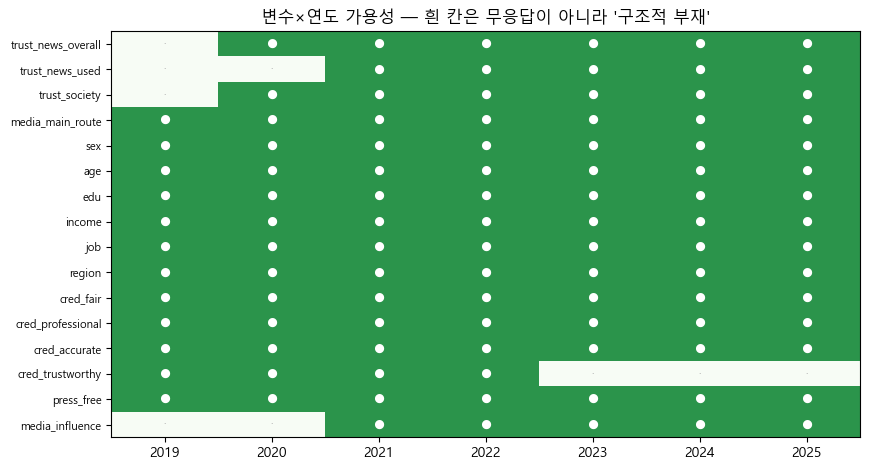

7개년 전부 존재 변수 11개 · cred 핵심3 포함 = True


In [10]:
# [시각화 ②] 가용성 행렬 — 존재(1)/부재(0) 히트맵
avail = mat.apply(lambda s: s.map(lambda x: 0 if x == "—" else 1))
fig, ax = plt.subplots(figsize=(8.8, max(3.2, 0.30 * len(avail))))
ax.imshow(avail.values, cmap="Greens", vmin=0, vmax=1.4, aspect="auto")
ax.set_xticks(range(avail.shape[1])); ax.set_xticklabels(avail.columns)
ax.set_yticks(range(avail.shape[0])); ax.set_yticklabels(avail.index, fontsize=8)
for i in range(avail.shape[0]):
    for j in range(avail.shape[1]):
        ax.text(j, i, "●" if avail.values[i, j] else "·", ha="center", va="center",
                color="white" if avail.values[i, j] else "#999", fontsize=8)
ax.set_title("변수×연도 가용성 — 흰 칸은 무응답이 아니라 '구조적 부재'")
fig.tight_layout(); plt.show()
full = avail.index[avail.sum(axis=1) == avail.shape[1]].tolist()
core3 = {"cred_fair", "cred_professional", "cred_accurate"}
print(f"7개년 전부 존재 변수 {len(full)}개 · cred 핵심3 포함 = {core3 <= set(full)}")

#### **[발견 ⑤] 빈칸은 '무응답'이 아니라 '구조적 부재'다**

`trust_news_overall`(2019 부재)·`trust_news_used`(2019·2020 부재)·`cred_trustworthy`(2023~ 부재)·`media_influence`(2019·2020 부재)의 빈칸은 전부 **문항 도입/폐지** 때문이다. 응답자가 답을 안 한 게 아니라, 그 해 설문지에 문항 자체가 없었다. 따라서 결측 처리는 '대치'가 아니라 '구조적 부재로 명시'가 원칙(P3).

→ **⑤ 가용성 행렬 — 완료(결측의 성격 = 구조적 부재 확정).**

### **Decision Box ② — 결측 처리 원칙: 평균대치 ✗ → 구조적 부재로 명시**

**기준: 연도×변수 행렬의 빈칸을 '무응답'으로 볼 것인가, '문항 부재'로 볼 것인가.**

| 후보 | 처리 | 위험 | 판정 |
|------|------|------|------|
| 평균/회귀 대치 | 빈칸을 추정값으로 채움 | 없던 문항을 *있었던 것처럼* 날조 → 추세 왜곡 | **금지** |
| 단순 listwise | 빈칸 포함 행 제거 | 구조적 부재 연도가 통째로 사라짐 | 부적절 |
| **구조적 부재 명시** | 빈칸 = "그 해 미측정"으로 라벨, 비교집합을 가용 연도로 한정 | 정보 손실 없음, 비교 정직 | **채택** |

**왜 명시인가**: 무응답(MAR/MCAR)과 문항 부재는 본질이 다르다. 전자는 대치 대상이지만, 후자를 대치하면 "존재하지 않았던 측정"을 만들어낸다.
→ MGCFA·추세는 각 지표의 *가용 연도 집합*에서만 비교하고(핵심3지표=2019~2025 전체), 부분 가용 지표는 민감도 모형으로 분리한다(노트북 21).


## 6. 검증 셀 — docs 수치와 일치하는가 (입증)

In [11]:
EXPECT_N = {2019: 5040, 2020: 5010, 2021: 5010, 2022: 58936, 2023: 5000, 2024: 6000, 2025: 6000}
EXPECT_ENC = {2019: "euc-kr", 2020: "euc-kr", 2021: "utf-8", 2022: "utf-8",
              2023: "euc-kr", 2024: "euc-kr", 2025: "euc-kr"}
for y in hz.YEARS:
    n, enc = META[y][0].number_rows, META[y][1]
    assert n == EXPECT_N[y], f"{y} N 불일치: {n} != {EXPECT_N[y]}"
    assert enc == EXPECT_ENC[y], f"{y} 인코딩 불일치: {enc} != {EXPECT_ENC[y]}"
assert len(common_all) == 2, f"7개년 공통 변수명 != 2 (={len(common_all)})"
assert all(core_avail[y] == 3 for y in hz.YEARS), "핵심3지표가 7개년 전부 가용이 아님"
print("PASS — 연도별 N·인코딩·공통변수(2개)·핵심3지표 7개년 가용 모두 docs와 일치.")

PASS — 연도별 N·인코딩·공통변수(2개)·핵심3지표 7개년 가용 모두 docs와 일치.


## **7. 종합 — P2에서 무엇을 알게 됐나**

### **7-1. 연구 질문 답**
- **Q1(직결 가능성)**: **불가**. 공통 변수명 단 2개·인코딩 3종·가중치명 4종 → 변수명 직결은 깨지고, **의미기반 crosswalk**가 유일한 통합 키다(§1·§2, DB①).
- **Q2(2022)**: **오류 아님 — 대규모 개인표본**(N=58,936, 타 연도 ~10배). 통합 패널에서 표본지배를 일으키므로 P3에서 `wt_year_eq`로 균등화한다(§3).
- **Q3(잠재요인 입력)**: 핵심3지표{공정·전문·정확}가 **7개년 연속** 존재 → MGCFA·정렬법의 입력 정당성 확보. 부분 가용 지표는 민감도로 분리(§4·§5, DB②).

### **7-2. 단계별 요약**

| § | 검사한 난제 | 발견 | 판정 |
|:--:|------|------|:--:|
| ① | 메타 이질성 | 인코딩 3종·가중치명 4종 | fallback·표준화로 흡수 |
| ② | 변수명 직결 | 공통 단 2개, Jaccard 0.10~0.73 | crosswalk 필수(DB①) |
| ③ | 2022 표본 | N=58,936 대규모 개인표본 | 오류 아님 → 가중 보정 |
| ④ | 배터리 가용성 | 핵심3지표 7개년 연속 | MGCFA 입력 확정 |
| ⑤ | 결측 성격 | 빈칸 = 구조적 부재 | 명시 처리(DB②) |

### **7-3. `src/extract_all_sav_meta.py` 코드리뷰 결론**
- **메타 추출 정확**: 7개년 N·변수수·인코딩·가중치명을 정확히 산출, 마스터플랜 §1 표와 일치.
- 단, 원 스크립트는 전체 로드 후 메타만 사용 → 본 노트북처럼 `metadataonly=True`가 더 효율적(기능 동일, 성능 개선 *여지*만 기록, 강제수정 불필요 — 과잉수정 금지 원칙).
- → **결함 없음. 강제 수정 없이 리뷰 통과.**

### **7-4. 다음 단계**
4난제가 모두 규명되고 통합 키(crosswalk)·잠재요인 입력(핵심3지표)이 확정됐으므로, 이제 **이 crosswalk를 실제로 적용해 패널을 빌드**한다 →
[`11-data-prep-harmonize.ipynb`](11-data-prep-harmonize.ipynb)(P3, 90,996행 패널 빌드·검증) → 20(통합 EDA) → 21~24(MGCFA·교차검증·정렬·APC) → 30(P5 종합).

> ✅ 본 노트북 수치는 *데이터 이해용 실측치*다. KPF 원자료 재검증(노트북 `12`, 공식 보고서와 전 셀 일치)이 완료되어, 확정 인용 자격은 p6-pdf-structure §3 표를 따른다.
